In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Load the raw CSV, skipping row 2 which is metadata, not real data
df = pd.read_csv("/content/drive/MyDrive/wfp_food_prices_nga.csv", skiprows=[1])

# Convert the data column from text to an actual datatime type,
# so pandas can do time-based operations (grouping by month, shifting etc.)

df["date"] = pd.to_datetime(df["date"])

# Force the price column to be numeric. Any value that can't convert
# (like stray text) becomes NaN instead of crashing the script.

df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Drop rows where price is missing - we can't use them for forecasting anyway

df = df.dropna(subset=["price"])

In [ ]:
#table with one column per state, aligned by month


commodity = "Maize (white)"
unit = "100 KG"
states = ["Oyo", "Lagos", "Kano"]

# Filter down to just this commodity, this unit, and our 3 states of interest
pivot = df[(df["commodity"] == commodity) & (df["unit"] == unit) & (df["admin1"].isin(states))]

# pivot_table reshapes the data: one row per month, one column per state,
# with the average price in each cell (aggfunc="mean" handles cases where
# a state has more than one market reporting that month )

pt = pivot.pivot_table(
    index=pd.Grouper(key="date", freq="MS"), # group rows into calendar months
    columns="admin1",        # one clumn per state
    values="price",
    aggfunc="mean"
)


# Only keep months where ALL THREE states have a price - otherwise we can't
# fairly compare them side by side. this is a real limitation worth noting:
# it can shrink your useable data a lot (in mt test, from 150 months down to 51)

pt = pt.dropna()

print("Months with all 3 states availbale:", len(pt))
pt.head()

Months with all 3 states availbale: 51


admin1,Kano,Lagos,Oyo
date,,,
2012-05-01,6800.0,7000.0,6500.0
2012-07-01,6700.0,7300.0,7000.0
2012-08-01,6500.0,7460.0,7000.0
2012-12-01,6300.0,7250.0,5800.0
2013-06-01,8500.0,8000.0,8575.0


In [ ]:
# build the feature that allow yesterday Kano price  to predict todays LAgos price


# We're building a small feature table by hand here, one column at a time,
# so it's clear exactly what each column represents.

feat = pd.DataFrame(index=pt.index)

feat["lagos_t"] = pt["Lagos"]  # the value we're trying to predict (this month's lagos price)
feat["lagos_lag1"]= pt["Lagos"].shift(1) # Lagos own price last month (our baseline predictor)
feat["kano_lag1"] = pt["Kano"].shift(1) # kano price last month (the extra predictor we are testing)
feat["oyo_lag1"] = pt["Oyo"].shift(1) # Oyo price last month (the additional predictor)

# shift(1) creates NaN for the very first row (there is no last month for it)
# so we frop row where we dont have a complete set of features yet

feat = feat.dropna()

print("Rows available after creating lag features:", len(feat))

Rows available after creating lag features: 50


In [ ]:
# comparing lagos history with Lagos + kano togrether

# Hold out the last 12 months as a test set - everything before this is for training

n_test = 12
train = feat.iloc[:-n_test]
test = feat.iloc[-n_test:]

# Define y_test here, before it's used in baseline calculations
y_test = test["lagos_t"]

# --- Model A: the baseline — just use last month's Lagos price to predict this month's ---
# (this is the "naive" forecast we've used in every stage so far)

# Baseline Model
baseline_pred = test["lagos_lag1"]
baseline_mape = mean_absolute_percentage_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

x_train = train[["lagos_lag1", "kano_lag1", "oyo_lag1"]]
y_train = train["lagos_t"]
x_test = test[["lagos_lag1", "kano_lag1", "oyo_lag1"]]

model = LinearRegression()
model.fit(x_train, y_train) # learn the best weights for lagos_lag1, kano_lag1, and oyo_lag1
combined_pred = model.predict(x_test)

combined_mape = mean_absolute_percentage_error(y_test, combined_pred)
combined_r2 = r2_score(y_test, combined_pred)

print(f"Baseline (Lagos's own lag only)  - MAPE: {baseline_mape*100:.2f}% R²:{baseline_r2:.3f}")
print(f"Lagos + Kano + Oyo lag combined  - MAPE: {combined_mape*100:.2f}% R²: {combined_r2:.3f}")

# The model's learned weights tell us how much each input matters:
# a bigger coefficient on kano_lag1 relative to lagos_lag1 = Kano genuinely adds signal

print(f"\nLearned weight - Lagos lag: {model.coef_[0]:.3f}, kano lag: {model.coef_[1]:.3f}, oyo lag: {model.coef_[2]:.3f}")

Baseline (Lagos's own lag only)  - MAPE: 10.00% R²:-0.294
Lagos + Kano + Oyo lag combined  - MAPE: 7.94% R²: 0.139

Learned weight - Lagos lag: -0.181, kano lag: 0.005, oyo lag: 1.160


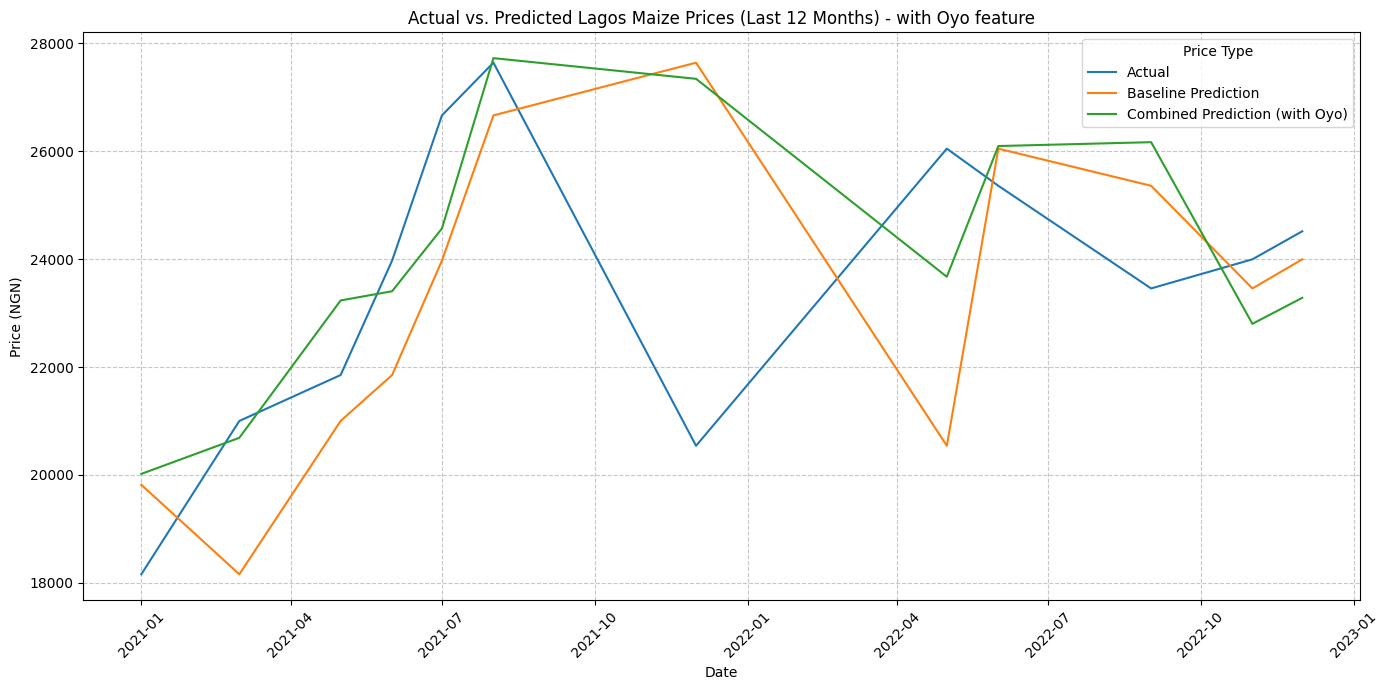

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easy plotting with updated predictions
plot_df = pd.DataFrame({
    'Actual': y_test,
    'Baseline Prediction': baseline_pred,
    'Combined Prediction (with Oyo)': combined_pred
}, index=y_test.index)

plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df, dashes=False)
plt.title('Actual vs. Predicted Lagos Maize Prices (Last 12 Months) - with Oyo feature')
plt.xlabel('Date')
plt.ylabel('Price (NGN)')
plt.legend(title='Price Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Addressing Multicollinearity with Ridge Regression

Given the observed multicollinearity when including the Oyo price, we'll now try Ridge regression. Ridge regression adds a penalty equivalent to the square of the magnitude of coefficients, which helps to shrink them towards zero and reduce their variance, thereby stabilizing the model in the presence of multicollinearity.

In [ ]:
from sklearn.linear_model import Ridge

# Initialize Ridge Regression model with an alpha (regularization strength)
# A common practice is to start with a default or tune it using cross-validation
ridge_model = Ridge(alpha=1.0) # You can experiment with different alpha values

# Fit the model on the training data
ridge_model.fit(x_train, y_train)

# Make predictions on the test set
ridge_pred = ridge_model.predict(x_test)

# Evaluate the Ridge model
ridge_mape = mean_absolute_percentage_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print(f"Ridge Regression (Lagos + Kano + Oyo) - MAPE: {ridge_mape*100:.2f}% R²: {ridge_r2:.3f}")
print(f"\nLearned weights - Lagos lag: {ridge_model.coef_[0]:.3f}, Kano lag: {ridge_model.coef_[1]:.3f}, Oyo lag: {ridge_model.coef_[2]:.3f}")

# Compare with previous models
print(f"\n--- Comparison ---")
print(f"Baseline (Lagos's own lag only)       - MAPE: {baseline_mape*100:.2f}% R²:{baseline_r2:.3f}")
print(f"Linear Regression (Lagos + Kano + Oyo) - MAPE: {combined_mape*100:.2f}% R²: {combined_r2:.3f}")

Ridge Regression (Lagos + Kano + Oyo) - MAPE: 7.94% R²: 0.139

Learned weights - Lagos lag: -0.181, Kano lag: 0.005, Oyo lag: 1.160

--- Comparison ---
Baseline (Lagos's own lag only)       - MAPE: 10.00% R²:-0.294
Linear Regression (Lagos + Kano + Oyo) - MAPE: 7.94% R²: 0.139


### Model and Plot for Lagos + Kano Predictors (excluding Oyo)

To fulfill your request for a LinkedIn image specifically showing the model with only Lagos and Kano as predictors, we will re-train a Linear Regression model with just these two features and then generate a dedicated plot.

In [ ]:
# Prepare data for the 2-feature model (Lagos + Kano only)
x_train_2_features = train[['lagos_lag1', 'kano_lag1']]
x_test_2_features = test[['lagos_lag1', 'kano_lag1']]

# Train a new Linear Regression model with only 2 features
model_2_features = LinearRegression()
model_2_features.fit(x_train_2_features, y_train)
combined_pred_2_features = model_2_features.predict(x_test_2_features)

# Evaluate this 2-feature model
combined_mape_2_features = mean_absolute_percentage_error(y_test, combined_pred_2_features)
combined_r2_2_features = r2_score(y_test, combined_pred_2_features)

print(f"Linear Regression (Lagos + Kano only) - MAPE: {combined_mape_2_features*100:.2f}% R²: {combined_r2_2_features:.3f}")
print(f"Learned weights (Lagos + Kano only) - Lagos lag: {model_2_features.coef_[0]:.3f}, Kano lag: {model_2_features.coef_[1]:.3f}")

# Compare with previous models (for context)
print(f"\n--- Comparison ---")
print(f"Baseline (Lagos's own lag only)        - MAPE: {baseline_mape*100:.2f}% R²:{baseline_r2:.3f}")
print(f"Linear Regression (Lagos + Kano + Oyo) - MAPE: {combined_mape*100:.2f}% R²: {combined_r2:.3f}")

Linear Regression (Lagos + Kano only) - MAPE: 7.61% R²: 0.193
Learned weights (Lagos + Kano only) - Lagos lag: 0.423, Kano lag: 0.636

--- Comparison ---
Baseline (Lagos's own lag only)        - MAPE: 10.00% R²:-0.294
Linear Regression (Lagos + Kano + Oyo) - MAPE: 7.94% R²: 0.139


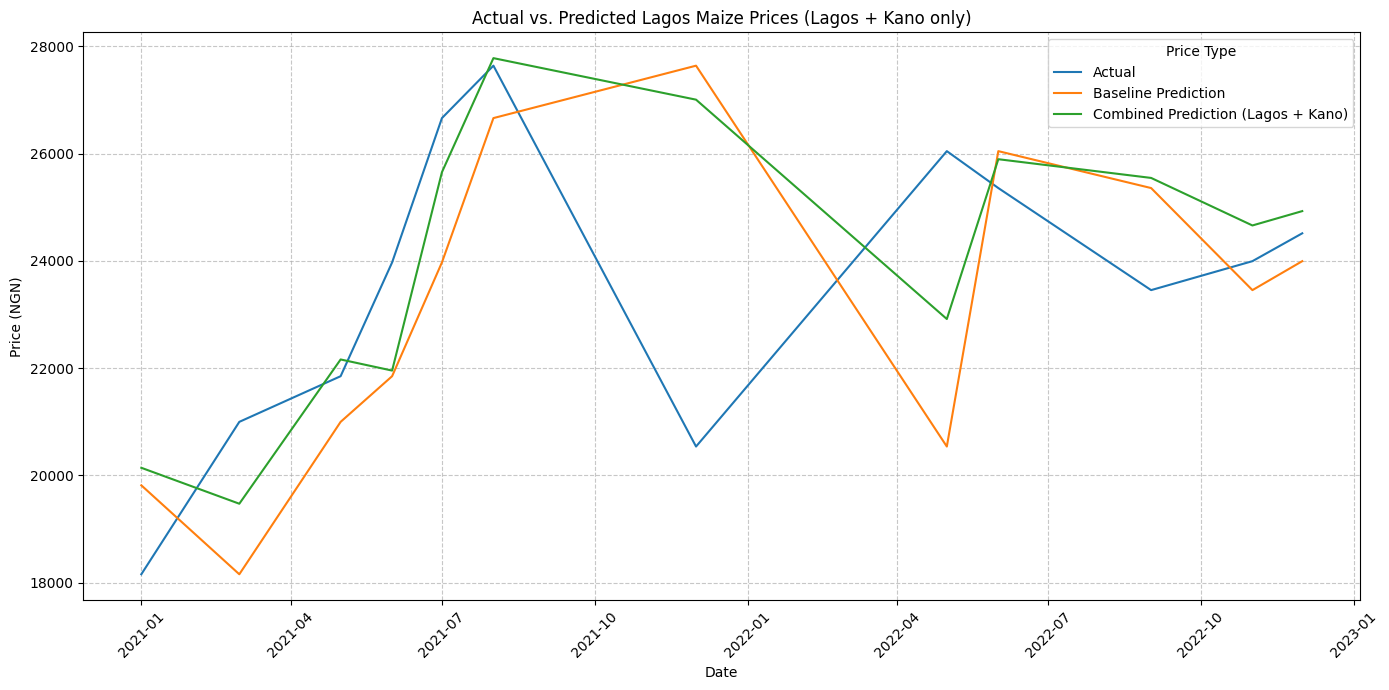

In [ ]:
# Create a DataFrame for plotting the 2-feature model
plot_df_2_features = pd.DataFrame({
    'Actual': y_test,
    'Baseline Prediction': baseline_pred,
    'Combined Prediction (Lagos + Kano)': combined_pred_2_features
}, index=y_test.index)

plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df_2_features, dashes=False)
plt.title('Actual vs. Predicted Lagos Maize Prices (Lagos + Kano only)')
plt.xlabel('Date')
plt.ylabel('Price (NGN)')
plt.legend(title='Price Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('lagos_maize_predictions_lagos_kano.png', dpi=300, bbox_inches='tight') # Save the figure
plt.show()

We can also visualize the Ridge regression predictions against the actual prices and the other models to see how it compares graphically.

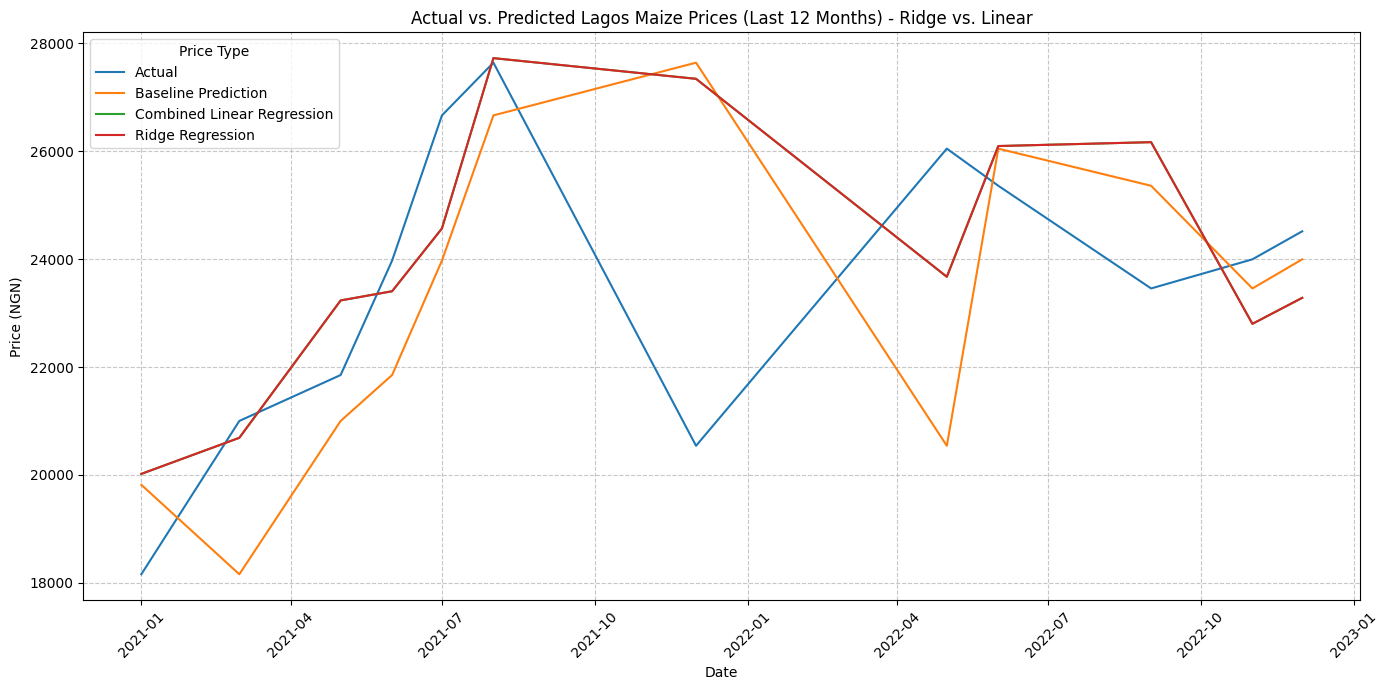

In [ ]:
# Create a DataFrame for easy plotting with updated predictions including Ridge
plot_df_ridge = pd.DataFrame({
    'Actual': y_test,
    'Baseline Prediction': baseline_pred,
    'Combined Linear Regression': combined_pred,
    'Ridge Regression': ridge_pred
}, index=y_test.index)

plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df_ridge, dashes=False)
plt.title('Actual vs. Predicted Lagos Maize Prices (Last 12 Months) - Ridge vs. Linear')
plt.xlabel('Date')
plt.ylabel('Price (NGN)')
plt.legend(title='Price Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

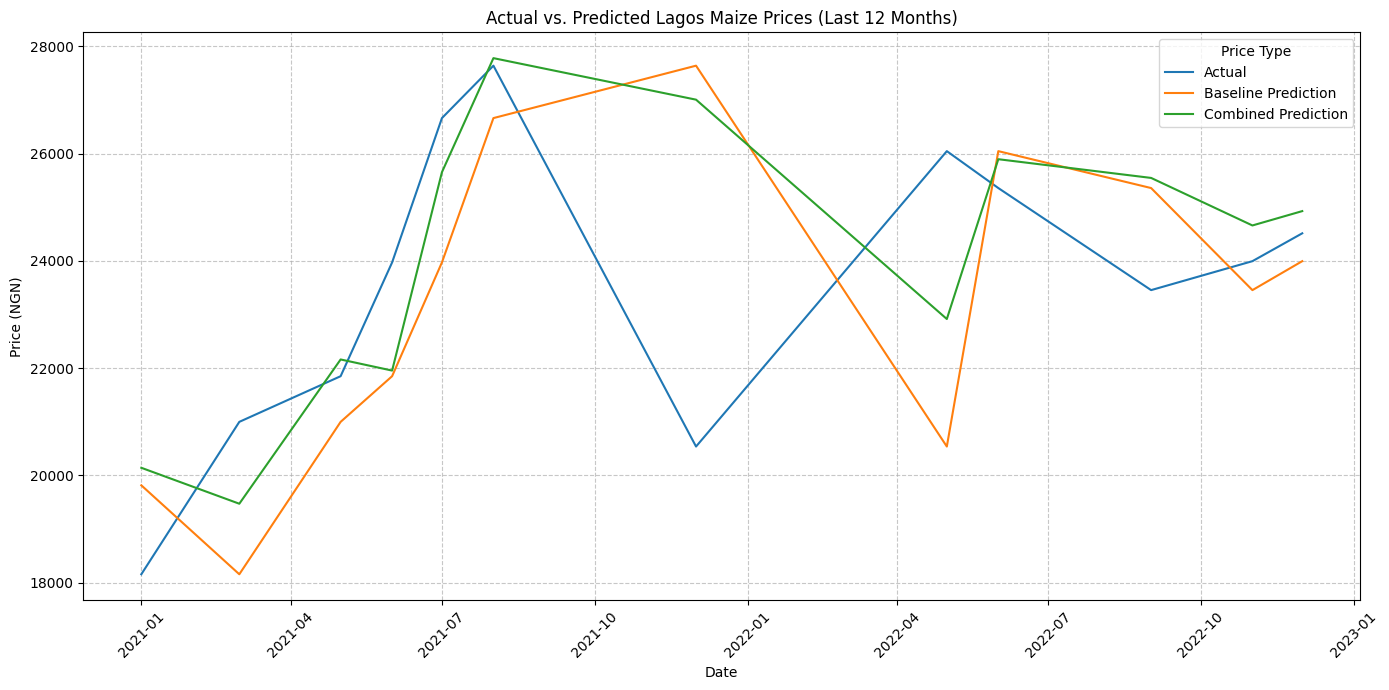

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easy plotting
plot_df = pd.DataFrame({
    'Actual': y_test,
    'Baseline Prediction': baseline_pred,
    'Combined Prediction': combined_pred
}, index=y_test.index)

plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df, dashes=False)
plt.title('Actual vs. Predicted Lagos Maize Prices (Last 12 Months)')
plt.xlabel('Date')
plt.ylabel('Price (NGN)')
plt.legend(title='Price Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()